# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import joblib
from sklearn.model_selection import RandomizedSearchCV
import os
from scipy.stats import randint

# Loading Train Test

In [2]:
X_train = pd.read_parquet("/content/drive/MyDrive/Music_Recom_ML/Processed/X_train.parquet")
X_val = pd.read_parquet("/content/drive/MyDrive/Music_Recom_ML/Processed/X_val.parquet")

y_train = pd.read_parquet("/content/drive/MyDrive/Music_Recom_ML/Processed/y_train.parquet")
y_val = pd.read_parquet("/content/drive/MyDrive/Music_Recom_ML/Processed/y_val.parquet")

test_df = pd.read_parquet("/content/drive/MyDrive/Music_Recom_ML/Processed/test_encoded.parquet")

In [3]:
RESULTS_FILE = "/content/drive/MyDrive/Music_Recom_ML/Results/Model_results.csv"

if not os.path.exists(RESULTS_FILE):
    pd.DataFrame(columns=["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"]).to_csv(RESULTS_FILE, index=False)

# Training, Evaluation Functions

In [4]:
def evaluate_model(y_true, pred_probs):

  pred_labels = (pred_probs > 0.5).astype(int)

  accuracy = accuracy_score(y_true, pred_labels)
  precision = precision_score(y_true, pred_labels)
  recall = recall_score(y_true, pred_labels)
  f1 = f1_score(y_true, pred_labels)
  auc = roc_auc_score(y_true, pred_probs)

  return accuracy, precision, recall, f1, auc, pred_labels

In [5]:
def save_result(result_dict):

    df = pd.read_csv(RESULTS_FILE)

    df = pd.concat([df, pd.DataFrame([result_dict])], ignore_index=True)

    df.to_csv(RESULTS_FILE, index=False)

In [6]:
def train_model(model, name):

  model.fit(X_train, y_train)
  pred_probs = model.predict_proba(X_val)[:,1]
  accuracy, precision, recall, f1, auc, pred_labels = evaluate_model(y_val, pred_probs)

  cf = confusion_matrix(y_val, pred_labels)
  plt.figure(figsize=(4,3))
  sns.heatmap(cf, annot=True, fmt='d')
  plt.title(f"{name} Confusion Matrix")
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.show()

  model_filename = f"{name}.pkl".replace(" ","_")
  joblib.dump(model, f"/content/drive/MyDrive/Music_Recom_ML/Models/{model_filename}")

  result = {"Model": name, "Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1": f1, "AUC": auc}
  save_result(result)

In [ ]:
def train_model_subset(model, name, subset_X, subset_y):

  model.fit(subset_X, subset_y)
  pred_probs = model.predict_proba(X_val)[:,1]
  accuracy, precision, recall, f1, auc, pred_labels = evaluate_model(y_val, pred_probs)

  cf = confusion_matrix(y_val, pred_labels)
  plt.figure(figsize=(4,3))
  sns.heatmap(cf, annot=True, fmt='d')
  plt.title(f"{name} Confusion Matrix")
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.show()

  model_filename = f"{name}.pkl".replace(" ","_")
  joblib.dump(model, f"/content/drive/MyDrive/Music_Recom_ML/Models/{model_filename}")

  result = {"Model": name, "Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1": f1, "AUC": auc}
  save_result(result)

In [ ]:
def train_test_model_subset(model, name, subset_X, subset_y, val_X, val_y):

  model.fit(subset_X, subset_y)
  pred_probs = model.predict_proba(val_X)[:,1]
  accuracy, precision, recall, f1, auc, pred_labels = evaluate_model(val_y, pred_probs)

  cf = confusion_matrix(val_y, pred_labels)
  plt.figure(figsize=(4,3))
  sns.heatmap(cf, annot=True, fmt='d')
  plt.title(f"{name} Confusion Matrix")
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.show()

  model_filename = f"{name}.pkl".replace(" ","_")
  joblib.dump(model, f"/content/drive/MyDrive/Music_Recom_ML/Models/{model_filename}")

  result = {"Model": name, "Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1": f1, "AUC": auc}
  save_result(result)

In [51]:
def train_cluster_model(model, name):

  model.fit(X_train)
  pred_probs = model.predict(X_val)
  accuracy, precision, recall, f1, auc, pred_labels = evaluate_model(y_val, pred_probs)

  cf = confusion_matrix(y_val, pred_labels)
  plt.figure(figsize=(4,3))
  sns.heatmap(cf, annot=True, fmt='d')
  plt.title(f"{name} Confusion Matrix")
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.show()

  model_filename = f"{name}.pkl".replace(" ","_")
  joblib.dump(model, f"/content/drive/MyDrive/Music_Recom_ML/Models/{model_filename}")

  result = {"Model": name, "Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1": f1, "AUC": auc}
  save_result(result)

# Decision Tree - Base Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier

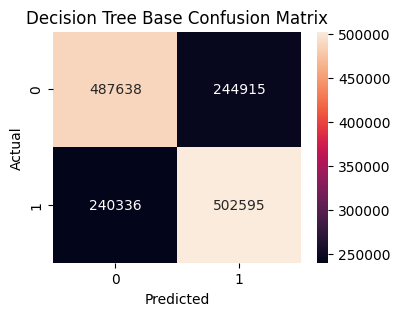

/tmp/ipykernel_25355/3531416747.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([result_dict])], ignore_index=True)


In [ ]:
train_model(DecisionTreeClassifier(random_state=42),"Decision Tree Base")

# Decision Tree - Tuned Model

In [ ]:
tune_X = X_train.sample(350000, random_state=42)
tune_y = y_train.loc[tune_X.index]

In [ ]:
dt_params = {
    "max_depth": randint(5,30),
    "min_samples_split": randint(5,20),
    "min_samples_leaf": randint(1,10),
    "max_features": [None,"sqrt","log2"],
    "criterion": ["gini","entropy"]
}

dt_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=dt_params,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

dt_search.fit(tune_X, tune_y)

print("Best Parameters:")
print(dt_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters:
{'criterion': 'entropy', 'max_depth': 8, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 14}


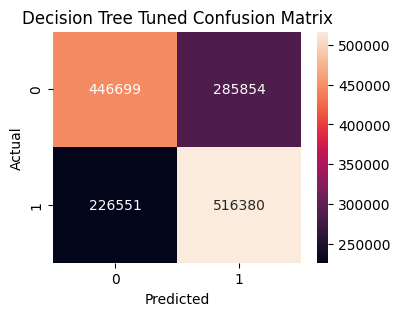

In [ ]:
best_dt = dt_search.best_estimator_

train_model(best_dt, "Decision Tree Tuned")

# Random Forest - Depth 2

In [ ]:
from sklearn.ensemble import RandomForestClassifier

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


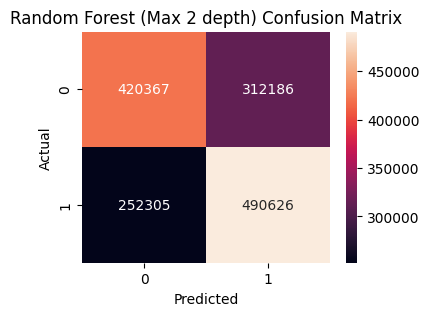

In [ ]:
train_model(RandomForestClassifier(n_estimators=100, max_depth=2, max_samples=0.3, n_jobs=-1),"Random Forest (Max 2 depth)")

# Random Forest - Depth 5

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


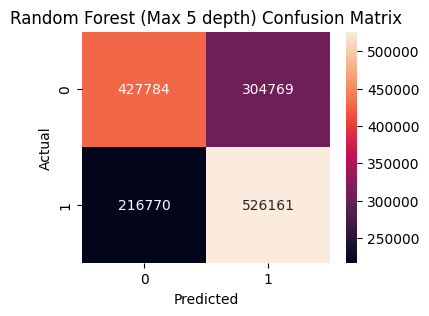

In [ ]:
train_model(RandomForestClassifier(n_estimators=100, max_depth=5, max_samples=0.3, n_jobs=-1),"Random Forest (Max 5 depth)")

# Random Forest - Tuned Model

In [ ]:
tune_X = X_train.sample(350000, random_state=42)
tune_y = y_train.loc[tune_X.index]

In [ ]:
rf_params = {
    "n_estimators": randint(50,100),
    "max_depth": randint(2,10),
    "max_samples": [0.3, 0.5, 0.7],
    "min_samples_leaf": randint(1,5)
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(n_jobs=-1, random_state=42),
    rf_params,
    n_iter=15,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

rf_search.fit(tune_X, tune_y)

print("Best Parameters:")
print(rf_search.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Best Parameters:
{'max_depth': 9, 'max_samples': 0.7, 'min_samples_leaf': 2, 'n_estimators': 74}


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


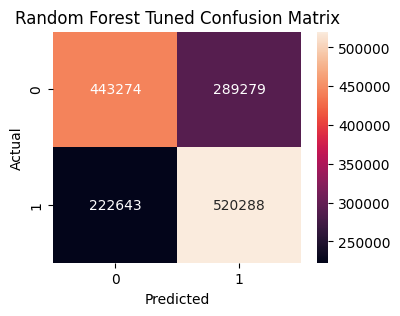

In [ ]:
best_rf = rf_search.best_estimator_

train_model(best_rf, "Random Forest Tuned")

# AdaBoost - Base Model

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


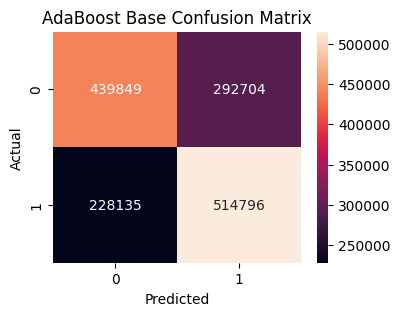

In [ ]:
train_model(AdaBoostClassifier(n_estimators=50), "AdaBoost Base")

# AdaBoost - Tuned Model

In [ ]:
tune_X = X_train.sample(350000, random_state=42)
tune_y = y_train.loc[tune_X.index]

In [ ]:
ada_params = {
    "n_estimators": randint(50,100),
    "learning_rate": [0.01,0.05,0.1,0.5,1]
}

ada_search = RandomizedSearchCV(
    AdaBoostClassifier(random_state=42),
    ada_params,
    n_iter=15,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

ada_search.fit(tune_X, tune_y)

print("Best Parameters:")
print(ada_search.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best Parameters:
{'learning_rate': 1, 'n_estimators': 84}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


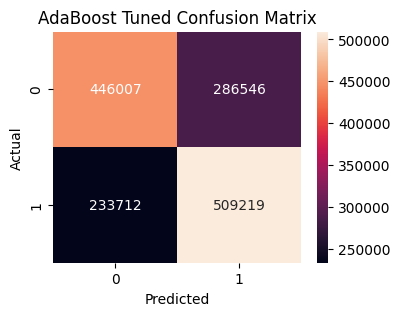

In [ ]:
best_ada = ada_search.best_estimator_

train_model(best_ada, "AdaBoost Tuned")

# KNN - k = 10

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
subset_X = X_train.sample(200000, random_state=42)
subset_y = y_train.loc[subset_X.index]

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


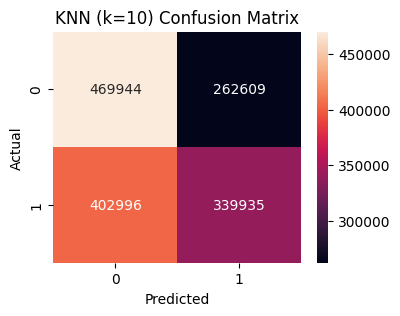

In [ ]:
train_model_subset(KNeighborsClassifier(n_neighbors=10), "KNN (k=10)", subset_X, subset_y)

# KNN - k = 50

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


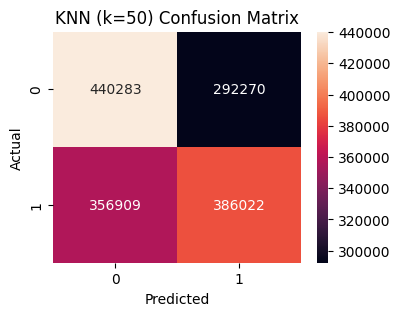

In [ ]:
train_model_subset(KNeighborsClassifier(n_neighbors=50), "KNN (k=50)", subset_X, subset_y)

# KNN - Tuned Model

In [ ]:
X_test_sample = X_val.sample(200000, random_state=42)
y_test_sample = y_val.loc[X_test_sample.index]

In [ ]:
knn_params = {
    "n_neighbors": randint(10,200),
    "weights": ["uniform","distance"],
    "metric": ["euclidean","manhattan"]
}

knn_search = RandomizedSearchCV(
    KNeighborsClassifier(),
    knn_params,
    n_iter=20,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

knn_search.fit(subset_X, subset_y)

print("Best Parameters:")
print(knn_search.best_params_)

Best Parameters:
{'metric': 'manhattan', 'n_neighbors': 148, 'weights': 'distance'}


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


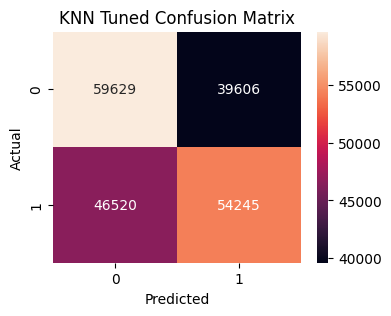

In [ ]:
best_knn = KNeighborsClassifier(n_neighbors=148, metric='manhattan', weights='distance')

train_test_model_subset(best_knn, "KNN Tuned", subset_X, subset_y, X_test_sample, y_test_sample)

# LightGBM - Base Model

In [7]:
import lightgbm as lgb

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


[LightGBM] [Info] Number of positive: 2971725, number of negative: 2930209
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.836406 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3380
[LightGBM] [Info] Number of data points in the train set: 5901934, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503517 -> initscore=0.014069
[LightGBM] [Info] Start training from score 0.014069


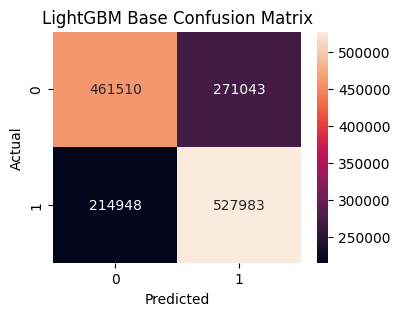

In [ ]:
train_model(lgb.LGBMClassifier(n_estimators=600, learning_rate=0.05), "LightGBM Base")

# LightGBM - Tuned Model

In [8]:
tune_X = X_train.sample(350000, random_state=42)
tune_y = y_train.loc[tune_X.index]

In [9]:
lgb_params = {
    "n_estimators": randint(300,1000),
    "learning_rate": [0.01,0.03,0.05,0.1],
    "num_leaves": [31,63,127],
    "max_depth": [-1,5,10,15],
    "subsample": [0.6,0.8,1],
    "colsample_bytree": [0.6,0.8,1]
}

lgb_search = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=42),
    lgb_params,
    n_iter=20,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

lgb_search.fit(tune_X, tune_y)

print("Best Parameters:")
print(lgb_search.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


[LightGBM] [Info] Number of positive: 176482, number of negative: 173518
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.060140 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3377
[LightGBM] [Info] Number of data points in the train set: 350000, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.504234 -> initscore=0.016938
[LightGBM] [Info] Start training from score 0.016938
Best Parameters:
{'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 822, 'num_leaves': 127, 'subsample': 1}


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


[LightGBM] [Info] Number of positive: 2971725, number of negative: 2930209
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.581619 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3376
[LightGBM] [Info] Number of data points in the train set: 5901934, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503517 -> initscore=0.014069
[LightGBM] [Info] Start training from score 0.014069


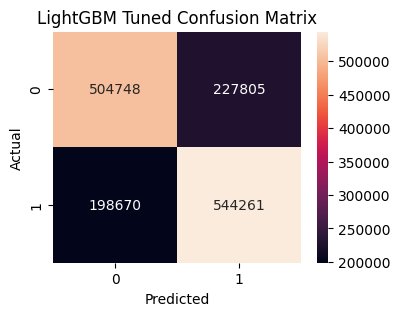

In [11]:
best_lgb = lgb_search.best_estimator_

train_model(best_lgb, "LightGBM Tuned")

# CatBoost - 300 Iters

In [ ]:
!pip install catboost

In [13]:
from catboost import CatBoostClassifier

0:	learn: 0.6880578	total: 2.45s	remaining: 12m 11s
1:	learn: 0.6814521	total: 4.74s	remaining: 11m 46s
2:	learn: 0.6778446	total: 7.8s	remaining: 12m 52s
3:	learn: 0.6728174	total: 10.2s	remaining: 12m 32s
4:	learn: 0.6690728	total: 12.1s	remaining: 11m 51s
5:	learn: 0.6674698	total: 13.9s	remaining: 11m 20s
6:	learn: 0.6636275	total: 15.8s	remaining: 11m 1s
7:	learn: 0.6603638	total: 17.6s	remaining: 10m 41s
8:	learn: 0.6578604	total: 19.4s	remaining: 10m 27s
9:	learn: 0.6560515	total: 22.6s	remaining: 10m 55s
10:	learn: 0.6535486	total: 25.7s	remaining: 11m 15s
11:	learn: 0.6514713	total: 27.9s	remaining: 11m 10s
12:	learn: 0.6499091	total: 29.8s	remaining: 10m 58s
13:	learn: 0.6483003	total: 31.7s	remaining: 10m 48s
14:	learn: 0.6469186	total: 33.5s	remaining: 10m 36s
15:	learn: 0.6456425	total: 35.7s	remaining: 10m 33s
16:	learn: 0.6439152	total: 39s	remaining: 10m 48s
17:	learn: 0.6429150	total: 41.4s	remaining: 10m 48s
18:	learn: 0.6419634	total: 43.2s	remaining: 10m 38s
19:	lea

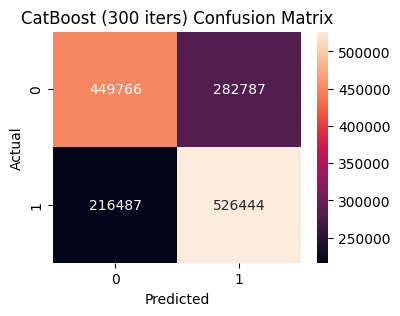

In [14]:
train_model(CatBoostClassifier(iterations=300, learning_rate=0.05, depth=8), "CatBoost (300 iters)")

# CatBoost - 1000 Iters

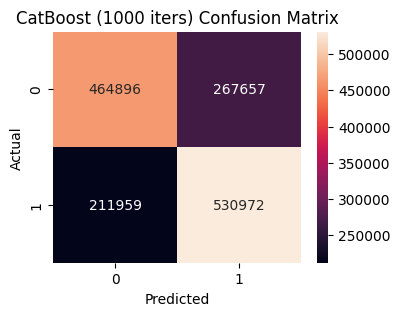

In [15]:
train_model(CatBoostClassifier(iterations=1000, learning_rate=0.05, depth=8, silent=True), "CatBoost (1000 iters)")

# CatBoost - Tuned Model

In [ ]:
tune_X = X_train.sample(350000, random_state=42)
tune_y = y_train.loc[tune_X.index]

In [18]:
cat_params = {
    "iterations": [600, 800, 1000, 1200],
    "learning_rate": [0.02, 0.03, 0.05, 0.07],
    "depth": [6, 7, 8, 9],
    "l2_leaf_reg": [1, 3, 5, 7],
    "bagging_temperature": [0, 0.5, 1],
    "random_strength": [0.5, 1, 2],
    "scale_pos_weight": [1, 1.3, 1.6, 2]
}

cb_search = RandomizedSearchCV(
    CatBoostClassifier(verbose=0),
    cat_params,
    n_iter=20,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

cb_search.fit(tune_X, tune_y)

print("Best Parameters:")
print(cb_search.best_params_)

Best Parameters:
{'scale_pos_weight': 1.6, 'random_strength': 1, 'learning_rate': 0.05, 'l2_leaf_reg': 7, 'iterations': 1000, 'depth': 9, 'bagging_temperature': 1}


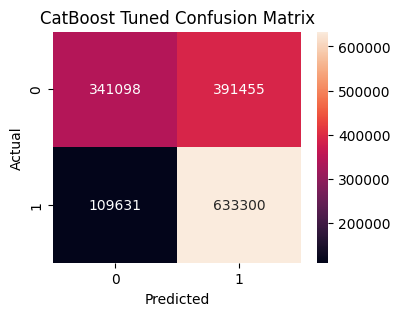

In [20]:
best_cat = cb_search.best_estimator_

train_model(best_cat, "CatBoost Tuned")

# XGBoost - Base Model

In [21]:
from xgboost import XGBClassifier

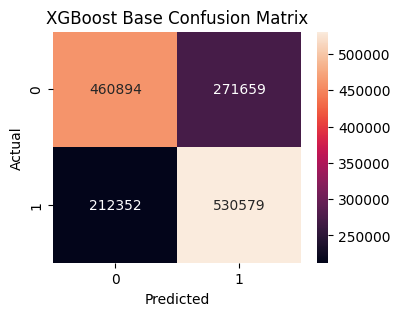

In [22]:
train_model(XGBClassifier(n_estimators=600, learning_rate=0.05), "XGBoost Base")

# XGBoost - Tuned Model

In [ ]:
tune_X = X_train.sample(350000, random_state=42)
tune_y = y_train.loc[tune_X.index]

In [23]:
xgb_params = {
    "n_estimators": randint(200, 800),
    "max_depth": randint(4, 10),
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1],
    "colsample_bytree": [0.7, 0.8, 0.9, 1],
    "gamma": [0, 0.1, 0.3, 0.5],
    "min_child_weight": [1, 3, 5]
}

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb_search = RandomizedSearchCV(
    xgb,
    param_distributions=xgb_params,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    verbose=2,
    n_jobs=-1
)

xgb_search.fit(tune_X, tune_y)

print("Best Parameters:")
print(xgb_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters:
{'colsample_bytree': 0.7, 'gamma': 0.5, 'learning_rate': 0.03, 'max_depth': 9, 'min_child_weight': 1, 'n_estimators': 778, 'subsample': 1}


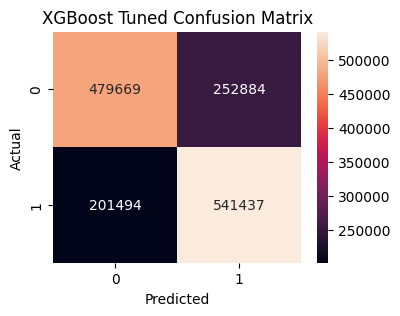

In [26]:
best_xgb = xgb_search.best_estimator_

train_model(best_xgb, "XGBoost Tuned")

# Logistic Regression

In [27]:
from sklearn.linear_model import LogisticRegression

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


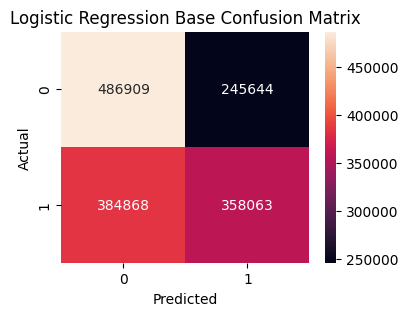

In [28]:
train_model(LogisticRegression(max_iter=1000, n_jobs=-1 ), "Logistic Regression Base")

# Gaussian Naive Bayes - Base Model

In [32]:
from sklearn.naive_bayes import GaussianNB

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


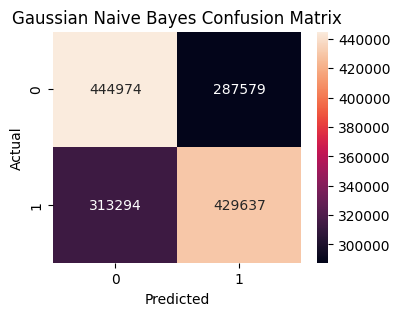

In [33]:
train_model(GaussianNB(), "Gaussian Naive Bayes")

# Gaussian Naive Bayes - Tuned Model

In [ ]:
tune_X = X_train.sample(350000, random_state=42)
tune_y = y_train.loc[tune_X.index]

In [34]:
gnb_params = {
    "var_smoothing": [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6]
}

gnb_search = RandomizedSearchCV(
    estimator=GaussianNB(),
    param_distributions=gnb_params,
    n_iter=7,
    scoring="roc_auc",
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

gnb_search.fit(tune_X, tune_y)

print("Best Parameters:")
print(gnb_search.best_params_)

Fitting 3 folds for each of 7 candidates, totalling 21 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best Parameters:
{'var_smoothing': 1e-10}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


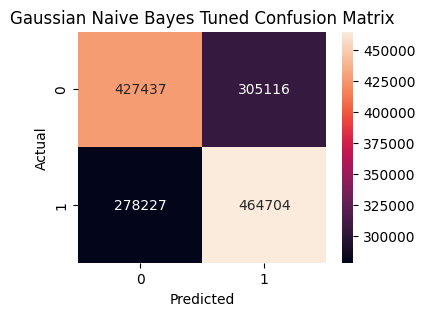

In [35]:
best_gnb = gnb_search.best_estimator_

train_model(best_gnb, "Gaussian Naive Bayes Tuned")

# K Means Clustering

In [36]:
from sklearn.cluster import KMeans

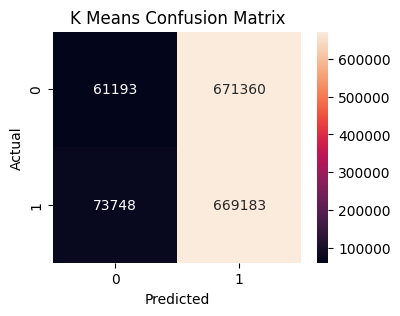

In [52]:
train_cluster_model(KMeans(n_clusters=2,init="random",random_state=42),"K Means")